## Pandas - 03

## Important DataFrame Functions

In [1]:
import numpy as np
import pandas as pd

In [60]:
marks = pd.DataFrame([
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,70,14],
    [80,70,14]
],columns= ["iq","marks","package"])
marks

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14
4,80,70,14


In [3]:
# 1. value_counts ( Series and DataFrame) ---> in dataframe --> gives the frequecny count of rows that how many times a row is repeated. (Mostly useful in Series.)
marks.value_counts()


iq   marks  package
80   70     14         2
100  80     10         1
90   70     7          1
120  100    14         1
Name: count, dtype: int64

In [51]:
ipl= pd.read_csv(r"ipl-matches.csv")
ipl.head(2)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


In [4]:
movies= pd.read_csv(r"movies.csv")
movies.head(2)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)


In [ ]:
# Questions on value_counts
# 1. find which player has won most potm --> in final and qualifiers
# My logic
matches= ipl[(ipl["MatchNumber"] == "Final") | (ipl["MatchNumber"] =="Qualifier 1") |(ipl["MatchNumber"] =="Qualifier 2") | (ipl["MatchNumber"] == "Eliminator")]
player= matches["Player_of_Match"].value_counts().index[0]
print(f"The Player which has won the most potm in final and qualifiers in ipl history is: {player}")

The Player which has won the most potm in final and qualifiers in ipl history is: SK Raina


In [6]:
# more improved code
ipl[~(ipl["MatchNumber"].str.isdigit())]["Player_of_Match"].value_counts()

Player_of_Match
F du Plessis         3
KA Pollard           3
SK Raina             3
JJ Bumrah            2
SR Watson            2
AB de Villiers       2
MK Pandey            2
M Vijay              2
YK Pathan            2
A Kumble             2
HH Pandya            1
JC Buttler           1
RM Patidar           1
DA Miller            1
VR Iyer              1
SP Narine            1
RD Gaikwad           1
TA Boult             1
MP Stoinis           1
KS Williamson        1
RR Pant              1
SA Yadav             1
Rashid Khan          1
AD Russell           1
KH Pandya            1
KV Sharma            1
NM Coulter-Nile      1
Washington Sundar    1
BCJ Cutting          1
DA Warner            1
MC Henriques         1
RG Sharma            1
A Nehra              1
V Sehwag             1
UT Yadav             1
Harbhajan Singh      1
BJ Hodge             1
MEK Hussey           1
MS Bisla             1
MS Dhoni             1
CH Gayle             1
MM Patel             1
DE Bollinger      

<Axes: >

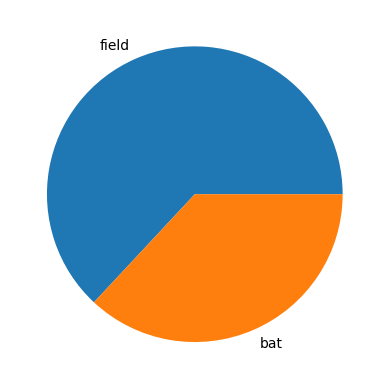

In [7]:
# 2. Toss Decision Plot --> plot a piechart graph that the teams after winning the toss do the bowling or batting.
ipl["TossDecision"].value_counts().plot(kind="pie")

In [67]:
# 3. How many matches each team has played?
(ipl["Team1"].value_counts() + ipl["Team2"].value_counts()).sort_values(ascending=False)
# note: You can perform any arithmetic operation on two series when index of the two series are same.


Team1
Mumbai Indians                 231
Royal Challengers Bangalore    226
Kolkata Knight Riders          223
Chennai Super Kings            208
Rajasthan Royals               192
Kings XI Punjab                190
Delhi Daredevils               161
Sunrisers Hyderabad            152
Deccan Chargers                 75
Delhi Capitals                  63
Pune Warriors                   46
Gujarat Lions                   30
Punjab Kings                    28
Gujarat Titans                  16
Rising Pune Supergiant          16
Lucknow Super Giants            15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [ ]:
# 2. sort_values("column_name", ascending = True or False)
movies.sort_values("title_x",ascending = False).head(3)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
939,Zor Lagaa Ke...Haiya!,tt1479857,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zor_Lagaa_Ke...H...,Zor Lagaa Ke... Haiya!,Zor Lagaa Ke... Haiya!,0,2009,\N,Comedy|Drama|Family,6.4,46,A tree narrates the story of four Mumbai-based...,Children build a tree-house to spy on a beggar...,NaN,Meghan Jadhav|Mithun Chakraborty|Riya Sen|Seem...,NaN,NaN
756,Zokkomon,tt1605790,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zokkomon,Zokkomon,Zokkomon,0,2011,109,Action|Adventure,4.0,274,After the passing of his parents in an acciden...,An orphan is abused and abandoned believed to...,Betrayal. Friendship. Bravery.,Darsheel Safary|Anupam Kher|Manjari Fadnnis|Ti...,NaN,22 April 2011 (India)


In [76]:
ipl.sort_values("Date").head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
949,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,N,Kolkata Knight Riders,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar


In [7]:
students= pd.DataFrame(
    {
    "name" : ["Hammad","Huzaifa","Ali",np.nan,"Haider",np.nan,"Ammar",np.nan,"Ahmed",np.nan],
    "college": ["bit","iit","vit",np.nan,np.nan,"vlsi","ssit",np.nan,np.nan,"git"],
    "branch" : ["eee", "it","cse",np.nan,"me","ce","civ","cse","bio",np.nan],
    "cgpa" : [6.66,8.25,6.41,np.nan,5.6,9.0,7.4,10,7.4,np.nan],
    "package": [4,5,6,np.nan,6,7,8,9,np.nan,np.nan]
}
)

students

,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,Haider,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,Ammar,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,Ahmed,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
students.sort_values("name") # --> default behaviour of sort_values is that NaN values goes to bottom
# using na_position = first --> NaN values goes to top (by default na_position = "last")
students.sort_values("name",na_position="first")

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
8,Ahmed,NaN,bio,7.40,NaN
2,Ali,vit,cse,6.41,6.0
6,Ammar,ssit,civ,7.40,8.0
4,Haider,NaN,me,5.60,6.0
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0


In [ ]:
# sort_values on multiple columns 
movies.sort_values(["year_of_release","title_x"],ascending=[True,False])
#--------------------Column_names in list--------->ascending=[True,False]


,year_of_release,title_x
1623,2001,Zubeidaa
1625,2001,Yeh Zindagi Ka Safar
1622,2001,Yeh Teraa Ghar Yeh Meraa Ghar
1620,2001,Yeh Raaste Hain Pyaar Ke
1573,2001,Yaadein (2001 film)
...,...,...
37,2019,Article 15 (film)
46,2019,Arjun Patiala
10,2019,Amavas
26,2019,Albert Pinto Ko Gussa Kyun Aata Hai?


In [ ]:
# 3: rank (series) ---> create a new series (column) of ranking  for the dataframe on the basis of given column.
batsman =pd.read_csv("batsman_runs_ipl.csv")
# batsman["Batting_rank"]= batsman["batsman_run"].rank() # by default it agranges in ascending order means low runs batter get better rank and vice versa.

# batsman.sort_values("Batting_rank")

In [ ]:
batsman["batting_rank"] = batsman["batsman_run"].rank(ascending= False)
batsman.sort_values("batting_rank") # sorting the data using the new added column rank that generates the rank from higher to lower using ascending = False

,batsman_run,batting_rank
batter,,
V Kohli,6634,1.0
S Dhawan,6244,2.0
DA Warner,5883,3.0
RG Sharma,5881,4.0
SK Raina,5536,5.0
...,...,...
V Pratap Singh,0,594.0
Abdur Razzak,0,594.0
U Kaul,0,594.0


In [5]:
# 4. sort_index (series and DataFrame) # ---> sort the index of the series or the dataframe
marks = {
    "math": 67,
    "english": 89,
    "science": 46,
    "urdu":100
}
mark_series = pd.Series(marks)
mark_series.sort_index() # in series

english     89
math        67
science     46
urdu       100
dtype: int64

In [ ]:
# in dataframe
movies.sort_index(ascending = False) # sort the index in descending order.

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1628,Humsafar,tt2403201,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Humsafar,Humsafar,Humsafar,0,2011,35,Drama|Romance,9.0,2968,Sara and Ashar are childhood friends who share...,Ashar and Khirad are forced to get married due...,NaN,Fawad Khan|,NaN,TV Series (2011–2012)
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)


In [67]:
# 5. set_index (dataframe) ---> set a specific column of dataframe as index
batsman.set_index("batter",inplace=True) # permanent change
batsman


,batsman_run
batter,
A Ashish Reddy,280
A Badoni,161
A Chandila,4
A Chopra,53
A Choudhary,25
...,...
Yash Dayal,0
Yashpal Singh,47
Younis Khan,3


In [64]:
# 6. reset_index ---> make the index column a normal column and indexes will be default.
batsman.reset_index() # temporary operation
batsman

,batsman_run
batter,
A Ashish Reddy,280
A Badoni,161
A Chandila,4
A Chopra,53
A Choudhary,25
...,...
Yash Dayal,0
Yashpal Singh,47
Younis Khan,3


In [ ]:
# batsman.reset_index(inplace= True) # permanent
batsman

,batter,batsman_run
0,A Ashish Reddy,280
1,A Badoni,161
2,A Chandila,4
3,A Chopra,53
4,A Choudhary,25
...,...,...
600,Yash Dayal,0
601,Yashpal Singh,47
602,Younis Khan,3
603,Yuvraj Singh,2754


In [68]:
# how to replace the exisiting index column without loosing it.
batsman.reset_index().set_index("batsman_run")

,batter
batsman_run,
280,A Ashish Reddy
161,A Badoni
4,A Chandila
53,A Chopra
25,A Choudhary
...,...
0,Yash Dayal
47,Yashpal Singh
3,Younis Khan


In [ ]:
batsman.reset_index().set_index("batter") # this  is the way to replace the exisiting index column without loosing the column

,batsman_run
batter,
A Ashish Reddy,280
A Badoni,161
A Chandila,4
A Chopra,53
A Choudhary,25
...,...
Yash Dayal,0
Yashpal Singh,47
Younis Khan,3


In [71]:
mark_series

math        67
english     89
science     46
urdu       100
dtype: int64

In [ ]:
# Series to DataFram Using  reset_index() (Useful)
mark_series.reset_index() # series become dataframe (very useful for later use.)

,index,0
0,math,67
1,english,89
2,science,46
3,urdu,100


In [ ]:

type(mark_series.reset_index()) 


pandas.DataFrame

In [ ]:
# 7. rename(dataframe) ---> 
# 1st use case: rename the name of any column of the dataframe
movies.set_index("title_x",inplace=True)


In [15]:
movies.rename(columns= {"imdb_id": "imdb","poster_path":"link"},inplace=True)


In [17]:
movies.head(3)

,imdb,link,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
title_x,,,,,,,,,,,,,,,,,
Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)


In [25]:
# 2nd use case: use rename() to change the index using index parameter.
movies.rename(index={"Uri: The Surgical Strike":"Uri","Battalion 609":"Battalion"}).head(3)# temporary change for permanent change use inplace = True


,imdb,link,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
title_x,,,,,,,,,,,,,,,,,
Uri,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
Battalion,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)


In [29]:
#  8: unique() (series) ---> returns out only unique values in numpy array from the series (not duplicated/repeated values)
# note: also count missing values if there are multiple missing values they only treat them as one.
series= pd.Series([1,1,2,3,3,4,4,5,5,6,np.nan,np.nan])
series.unique()

array([ 1.,  2.,  3.,  4.,  5.,  6., nan])

In [36]:
# Q: How many seasons ipl have according to this dataset?
ipl["Season"].unique().shape[0]

15

In [ ]:
# 9: nunique() (Series) ---> returns the number of unique values in a series.

# Note: nunique will not count the missing values.
ipl["Season"].nunique() # simple method to do this instead of above method.

15

In [ ]:
len(series.unique()) # counts the missing value once

7

In [ ]:
series.nunique() # doesn't count the missing value at all.

6

In [46]:
# 10: isnull() (Series + dataframe)
students["name"][students["name"].isnull()]

3    NaN
5    NaN
7    NaN
9    NaN
Name: name, dtype: str

In [ ]:
# in dataframe --> do not need of boolean masking
students.isnull() # applies to the whole dataframe

,name,college,branch,cgpa,package
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN


In [48]:
#11: notnull() (series + dataframe)---> inverse of isnull()
students["name"][students["name"].notnull()]

0     Hammad
1    Huzaifa
2        Ali
4     Haider
6      Ammar
8      Ahmed
Name: name, dtype: str

In [ ]:
# in dataframe --> it also doesn't need of boolean masking
# if entire row is nan then it will treat as nan
students.notnull()

,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,Haider,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,Ammar,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,Ahmed,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
# 12:hasnans---> Attribute(series) it checks whether the series has missing values or not and return its result in true or false.
students["name"].hasnans

True

# Dealing with Missing Values Methods

In [ ]:
# 13: dropna() (Series + dataframe)
students["name"].dropna() # in series

0     Hammad
1    Huzaifa
2        Ali
4     Haider
6      Ammar
8      Ahmed
Name: name, dtype: str

In [ ]:
students.dropna() # ----->  .dropna(how="any")(default)----> #in dataframe if there a single NaN value in a row it complete drop that row (default behavoiur)
# This is not a good way to deal with missing values we will loose a lot of data.


,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
6,Ammar,ssit,civ,7.40,8.0


In [ ]:
# condition is that we only want to remove those row that are completely NaN not a single column has a genunine value.
students.dropna(how= "all") # how = all will remove only that row in which all columns have a NaN value

,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
4,Haider,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,Ammar,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,Ahmed,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
# remove only that rows in which the column "name" has missing value.
# subset parameter ---> subset = ["column_name"]
students.dropna(subset=["name"])

,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
4,Haider,NaN,me,5.60,6.0
6,Ammar,ssit,civ,7.40,8.0
8,Ahmed,NaN,bio,7.40,NaN


In [25]:
students

,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,Haider,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,Ammar,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,Ahmed,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
# remove that rows in which the columns: "name" or "college" has missing values (Or operation)
students.dropna(subset=["name","college"])

,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
6,Ammar,ssit,civ,7.40,8.0


In [ ]:
# 14: fillna() (Series + DataFrame) # ---> fills the missing value provided in parenthesis.
students["name"].fillna("unknown") # in series

False

In [32]:
# in dataframe
students

,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,Haider,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,Ammar,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,Ahmed,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
# replace all the missing values in the dataframe with 0 (Not a good Idea to do it.)
students.fillna(0)

# Always fill the values column by column because every column is unique.

,name,college,branch,cgpa,package
0,Hammad,bit,eee,6.66,4.0
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
3,0,0,0,0.00,0.0
4,Haider,0,me,5.60,6.0
5,0,vlsi,ce,9.00,7.0
6,Ammar,ssit,civ,7.40,8.0
7,0,0,cse,10.00,9.0
8,Ahmed,0,bio,7.40,0.0
9,0,git,0,0.00,0.0


In [ ]:
students["package"].fillna(students["package"].mean()) # this is one of the strategy to deal with missing values.

0    4.000000
1    5.000000
2    6.000000
3    6.428571
4    6.000000
5    7.000000
6    8.000000
7    9.000000
8    6.428571
9    6.428571
Name: package, dtype: float64

In [ ]:
# method parameter
# ffill--> forward fill ---> means fill  this data to forward/upcoming missing value.
# bfill--> backward fill ---> means fill  this data to backward/sucessor missing value.
# note: This parameter in .fillna() is not working now. (I wil check it later.)

## Duplicate Values Function


In [ ]:
# 15: drop_duplicates()  (Series + Dataframe)
marks.drop_duplicates()  # default keep = "first"

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14


In [47]:
# keep = "last"
marks.drop_duplicates(keep= "last")

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
4,80,70,14


In [9]:
ipl.head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [ ]:
# Q: find the last match played by virat kohli in dehli. ---> Tricky Question
# My Logic
ipl["all_players"]= ipl["Team1Players"] +ipl["Team2Players"]
ipl["all_players"]

0      ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...
1      ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...
2      ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...
3      ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...
4      ['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...
                             ...                        
945    ['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...
946    ['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...
947    ['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...
948    ['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...
949    ['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...
Name: all_players, Length: 950, dtype: str

In [13]:
def did_kohli_play(players_list): # Custom logic using function
    return "V Kohli" in players_list




In [36]:
ipl["did_kohli_play"] = ipl["all_players"].apply(did_kohli_play)
kohli_delhi_matches = ipl[(ipl["City"] =="Delhi") & (ipl["did_kohli_play"] ==True)]
kohli_delhi_matches.sort_values("Date",inplace = True)

In [ ]:
last_match= kohli_delhi_matches.drop_duplicates("did_kohli_play",keep="last")
print(f"V Kohli Played ipl match at Delhi Last time in: {last_match["Season"].values}")

V Kohli Played ipl match at Delhi Last time in: <StringArray>
['2019']
Length: 1, dtype: str


In [58]:
# actual
ipl["all_players"]= ipl["Team1Players"] +ipl["Team2Players"]

def did_kohli_play(players_list): # Custom logic using function
    return "V Kohli" in players_list


ipl["did_kohli_play"] = ipl["all_players"].apply(did_kohli_play)
ipl[(ipl["City"] =="Delhi") & (ipl["did_kohli_play"] ==True)].drop_duplicates(subset= ["City","did_kohli_play"])


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,all_players,did_kohli_play
208,1178421,Delhi,2019-04-28,2019,46,Delhi Capitals,Royal Challengers Bangalore,Arun Jaitley Stadium,Delhi Capitals,bat,...,Runs,16.0,NaN,S Dhawan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...","['PA Patel', 'V Kohli', 'AB de Villiers', 'S D...",BNJ Oxenford,KN Ananthapadmanabhan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...",True


In [ ]:
# 16: drop(index=) (Series + DataFrame) --> index parameter
number= pd.Series([1,2,3,4,5,6,7,8,9,10])

# drop 5 and 10 from series
number.drop(index=[4,9]) # delete the index positions and its values. 

0    1
1    2
2    3
3    4
5    6
6    7
7    8
8    9
dtype: int64

In [ ]:
# in dataframe ---> deleting columns ---> columns parameter
students
# delete branch and cgpa columns
students.drop(columns= ["branch","cgpa"]) # temporary operation 
# for permanent : inplace = True Parameter


,name,college,package
0,Hammad,bit,4.0
1,Huzaifa,iit,5.0
2,Ali,vit,6.0
3,NaN,NaN,NaN
4,Haider,NaN,6.0
5,NaN,vlsi,7.0
6,Ammar,ssit,8.0
7,NaN,NaN,9.0
8,Ahmed,NaN,NaN
9,NaN,git,NaN


In [67]:
# in dataframe ---> deleting rows ---> index Parameter
# delete 0 and 8 row
students.drop(index=[0,8])

,name,college,branch,cgpa,package
1,Huzaifa,iit,it,8.25,5.0
2,Ali,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,Haider,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,Ammar,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN


In [71]:
# also applicable to labels
students.set_index("name").drop(index=["Hammad","Ahmed"])

,college,branch,cgpa,package
name,,,,
Huzaifa,iit,it,8.25,5.0
Ali,vit,cse,6.41,6.0
NaN,NaN,NaN,NaN,NaN
Haider,NaN,me,5.60,6.0
NaN,vlsi,ce,9.00,7.0
Ammar,ssit,civ,7.40,8.0
NaN,NaN,cse,10.00,9.0
NaN,git,NaN,NaN,NaN


In [ ]:
# 17: apply() (Series + Dataframe) # ----> apply any custom logic using functions in series and dataframe
# it traverses in column wise in series
temp= pd.Series([10,20,30,40,50])
def sigmoid(value):
    return 1/(1+np.exp(-(value)))

temp.apply(sigmoid)

0    0.999955
1    1.000000
2    1.000000
3    1.000000
4    1.000000
dtype: float64

In [79]:

points_df= pd.DataFrame(
    {
        "1st point": [(3,4),(-6,5),(0,0),(-10,1),(4,5)],
        "2nd point": [(-3,4),(0,0),(2,2),(10,10),(1,1)]
    }
)
points_df

,1st point,2nd point
0,"(3, 4)","(-3, 4)"
1,"(-6, 5)","(0, 0)"
2,"(0, 0)","(2, 2)"
3,"(-10, 1)","(10, 10)"
4,"(4, 5)","(1, 1)"


In [80]:
def euclidean(row):
    pt_A = row["1st point"]
    pt_B = row["2nd point"]
    return ((pt_A[0]-pt_B[0])**2 + (pt_A[1] - pt_B[1])**2)**0.5   # distance formula btw two points

points_df["euclidean_distance"] = np.round(points_df.apply(euclidean,axis=1),2) # axis=1 for traversing row-wise
points_df

,1st point,2nd point,euclidean_distance
0,"(3, 4)","(-3, 4)",6.00
1,"(-6, 5)","(0, 0)",7.81
2,"(0, 0)","(2, 2)",2.83
3,"(-10, 1)","(10, 10)",21.93
4,"(4, 5)","(1, 1)",5.00
